# General lead-time climatology products

Compute and save **monthly** lead-dependent climatologies for selected variables from any model component. The input contract is a monthly initialized-prediction cache with `L = 1, 2, ..., 24`, where `L=1` is the initialization month. The notebook discovers cache filenames, optionally regrids each native grid, preserves arbitrary additional dimensions (for example `lev` or soil depth), averages over ensemble member `M` when present, and writes explicit NetCDF products. Seasonal means can then be derived consistently from these reusable monthly climatologies.

Outputs use the component-aware layout:

```text
<S2D_DIAG_ROOT>/<source>/leadtime_acc/climatology/<component>/<variable>/
```

Unknown variables retain their input units. Optional scale/offset transforms can be configured when a common analysis unit is required. Existing products are not overwritten unless `FORCE = True`. The notebook refuses inputs without the complete `L=1..24` monthly coordinate.

In [1]:
from __future__ import annotations

import hashlib
import os
import uuid
from pathlib import Path

import numpy as np
import xarray as xr

S2D_DIAG_ROOT = Path("/global/cfs/cdirs/e3sm/S2S2D/s2d_diag")
from esp_lab.utils import regrid_utils as regrid

xr.set_options(keep_attrs=True)
print(f"Diagnostic root: {S2D_DIAG_ROOT}")

Diagnostic root: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag


## Selection and processing configuration

Each request independently selects sources, a component, variables, initialization months, and whether to regrid. Add requests for `land`, `ocn`, `ice`, or another component using the same structure. Keep `regrid=False` for caches already on their desired analysis grid or for non-latitude/longitude grids.

In [2]:
REQUESTS = [
    {
        # CESM-SMYLE currently has complete monthly caches. Add E3SM cases
        # here after their corresponding *_mon.nc caches are produced.
        "sources": ["CESM-SMYLE"],
        "component": "atm",
        "variables": ["PRECT", "TREFHT", "PSL"],
        "init_months": [5, 11],
        "regrid": True,
        "input_filename_contains": "mon",
    },
    # Example for analysis-ready land inputs:
    # {
    #     "sources": ["JRA55_FOSIRL", "Reanalysis"],
    #     "component": "land",
    #     "variables": ["H2OSNO", "H2OSOI"],
    #     "init_months": [5, 11],
    #     "regrid": False,
    #     "input_filename_contains": "monthly",
    # },
]

CLIMATOLOGY_YEARS = (1981, 2010)
EXPECTED_L = np.arange(1, 25)
FORCE = False

TARGET_DLAT = 1.0
TARGET_DLON = 1.0
REGRID_METHOD = "conservative"
REGRID_PERIODIC = True

OPEN_CHUNKS = {"Y": 3, "L": -1, "M": 2}
OUTPUT_CHUNKS = {"L": 1, "lat": 90, "lon": 180}

# Optional transforms: output = input * scale + offset. Unlisted variables
# retain their native values and units. Keys are (component, variable).
UNIT_TRANSFORMS = {
    ("atm", "PRECT"): {"scale": 1000.0 * 86400.0, "offset": 0.0, "units": "mm/day"},
    ("atm", "TREFHT"): {"scale": 1.0, "offset": -273.15, "units": "degC"},
    ("atm", "PSL"): {"scale": 1.0e-2, "offset": 0.0, "units": "hPa"},
}

# Use an exact path when automatic discovery finds multiple eligible files.
# Key: (source, component, variable, initialization_month).
INPUT_OVERRIDES = {
    # ("example_source", "ocn", "SST", 11): Path("/path/to/input.nc"),
}

assert CLIMATOLOGY_YEARS[0] <= CLIMATOLOGY_YEARS[1]

In [3]:
def expand_requests(requests):
    jobs = []
    seen = set()
    for request in requests:
        missing = {"sources", "component", "variables", "init_months"} - set(request)
        if missing:
            raise ValueError(f"Request is missing keys: {sorted(missing)}")
        component = str(request["component"])
        for source in request["sources"]:
            for variable in request["variables"]:
                for init_month in request["init_months"]:
                    job = (str(source), component, str(variable), int(init_month))
                    if not 1 <= job[3] <= 12:
                        raise ValueError(f"Invalid initialization month in {job}")
                    if job in seen:
                        raise ValueError(f"Duplicate request: {job}")
                    seen.add(job)
                    jobs.append({
                        "source": job[0],
                        "component": job[1],
                        "variable": job[2],
                        "init_month": job[3],
                        "regrid": bool(request.get("regrid", False)),
                        "input_filename_contains": str(request.get("input_filename_contains", "mon")),
                    })
    return jobs


def input_directory(job):
    return (S2D_DIAG_ROOT / job["source"] / "leadtime_acc" / "inputs"
            / job["component"] / job["variable"])


def is_eligible_input(path, variable):
    try:
        with xr.open_dataset(path, decode_times=False) as dataset:
            return (variable in dataset and {"Y", "L"} <= set(dataset[variable].dims)
                    and "time" in dataset and {"Y", "L"} <= set(dataset["time"].dims))
    except Exception:
        return False


def discover_input(job):
    key = (job["source"], job["component"], job["variable"], job["init_month"])
    if key in INPUT_OVERRIDES:
        path = Path(INPUT_OVERRIDES[key])
        if not path.exists():
            raise FileNotFoundError(f"Configured input override does not exist: {path}")
        return path

    directory = input_directory(job)
    month_variable = f"{job['init_month']:02d}_{job['variable']}"
    filename_token = job["input_filename_contains"].lower()
    candidates = sorted(
        path for path in directory.glob(f"*{month_variable}*.nc")
        if filename_token in path.name.lower() and is_eligible_input(path, job["variable"])
    )
    if not candidates:
        raise FileNotFoundError(
            f"No eligible Y/L input found for {key} in {directory}. "
            "Add INPUT_OVERRIDES[key] if its filename does not contain '<MM>_<variable>'."
        )
    if len(candidates) > 1:
        choices = "\n".join(f"  - {path}" for path in candidates)
        raise ValueError(f"Multiple eligible inputs found for {key}:\n{choices}\nUse INPUT_OVERRIDES.")
    return candidates[0]


def output_path(job, source_file):
    climy0, climy1 = CLIMATOLOGY_YEARS
    filename = f"{source_file.stem}_leadtime_climatology_{climy0}_{climy1}.nc"
    return (S2D_DIAG_ROOT / job["source"] / "leadtime_acc" / "climatology"
            / job["component"] / job["variable"] / filename)


def apply_unit_transform(data, component, variable):
    transform = UNIT_TRANSFORMS.get((component, variable))
    if transform is None:
        return data
    converted = data * float(transform.get("scale", 1.0)) + float(transform.get("offset", 0.0))
    converted.attrs.update(data.attrs)
    converted.attrs["units"] = transform["units"]
    converted.attrs["unit_transform"] = (
        f"output = input * {transform.get('scale', 1.0)} + {transform.get('offset', 0.0)}"
    )
    return converted


def grid_signature(dataset):
    if "lat" not in dataset.coords or "lon" not in dataset.coords:
        raise ValueError("Regridding requires lat and lon coordinates; set regrid=False for this request.")
    digest = hashlib.sha1()
    digest.update(np.asarray(dataset["lat"].values).tobytes())
    digest.update(np.asarray(dataset["lon"].values).tobytes())
    return digest.hexdigest()


def atomic_to_netcdf(dataset, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_name(f".{path.name}.tmp.{uuid.uuid4().hex}")
    encoding = {name: {"zlib": True, "complevel": 1}
                for name in dataset.data_vars if dataset[name].ndim > 0}
    try:
        dataset.to_netcdf(temporary, encoding=encoding)
        os.replace(temporary, path)
    finally:
        if temporary.exists():
            temporary.unlink()

## Discover and confirm inputs

Discovery requires the canonical component-aware directory and a filename containing `<initialization month>_<variable>`. `INPUT_OVERRIDES` handles exceptional names or multiple versions. Only datasets containing the selected variable plus compatible `time(Y,L)` coordinates are accepted. The compute cell additionally enforces the complete monthly `L=1..24` contract.

In [4]:
JOBS = expand_requests(REQUESTS)
for job in JOBS:
    job["input_path"] = discover_input(job)
    job["output_path"] = output_path(job, job["input_path"])
    print(
        f"{job['source']:16s} {job['component']:6s} {job['variable']:16s} "
        f"init={job['init_month']:02d} regrid={job['regrid']} "
        f"contains={job['input_filename_contains']!r}\n  {job['input_path']}"
    )
print(f"\nReady to produce {len(JOBS)} climatology products.")

CESM-SMYLE       atm    PRECT            init=05 regrid=True contains='mon'
  /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/leadtime_acc/inputs/atm/PRECT/BSMYLE05_PRECT_N20_M24_mon.nc
CESM-SMYLE       atm    PRECT            init=11 regrid=True contains='mon'
  /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/leadtime_acc/inputs/atm/PRECT/BSMYLE11_PRECT_N20_M24_mon.nc
CESM-SMYLE       atm    TREFHT           init=05 regrid=True contains='mon'
  /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/leadtime_acc/inputs/atm/TREFHT/BSMYLE05_TREFHT_N20_M24_mon.nc
CESM-SMYLE       atm    TREFHT           init=11 regrid=True contains='mon'
  /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/leadtime_acc/inputs/atm/TREFHT/BSMYLE11_TREFHT_N20_M24_mon.nc
CESM-SMYLE       atm    PSL              init=05 regrid=True contains='mon'
  /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/leadtime_acc/inputs/atm/PSL/BSMYLE05_PSL_N20_M24_mon.nc
CESM-SMYLE       atm    PSL              init=11 regrid=True cont

## Compute and save

The verification-time mask uses calendar years, so it works with decoded NumPy or CF calendars. Averaging is sequential over `M` and then `Y`, matching `esp_lab.stats.remove_drift`; variables without `M` are averaged over `Y` only.

In [ ]:
climy0, climy1 = CLIMATOLOGY_YEARS
target_grid = regrid.make_latlon_grid(dlat=TARGET_DLAT, dlon=TARGET_DLON)
regridders = {}

for job in JOBS:
    destination = job["output_path"]
    if destination.exists() and not FORCE:
        print(f"Exists, skipping: {destination}")
        continue

    print(f"Computing: {job['source']}, {job['component']}, {job['variable']}, init={job['init_month']:02d}")
    with xr.open_dataset(job["input_path"], chunks={}) as source_dataset:
        variable = job["variable"]
        actual_l = np.asarray(source_dataset["L"].values)
        if not np.array_equal(actual_l, EXPECTED_L):
            raise ValueError(
                f"{job['input_path']} has L={actual_l.tolist()}, but monthly climatology "
                f"requires L={EXPECTED_L.tolist()}"
            )
        values = source_dataset[variable]
        open_chunks = {name: size for name, size in OPEN_CHUNKS.items() if name in values.dims}
        if open_chunks:
            values = values.chunk(open_chunks)
        valid_time = source_dataset["time"].load()

        if job["regrid"]:
            signature = grid_signature(source_dataset)
            if signature not in regridders:
                regridders[signature] = regrid.make_regridder(
                    source_dataset, target_grid, method=REGRID_METHOD, periodic=REGRID_PERIODIC
                )
            values = regridders[signature](values)

        chunks = {name: size for name, size in OUTPUT_CHUNKS.items() if name in values.dims}
        if chunks:
            values = values.chunk(chunks)
        values = apply_unit_transform(values, job["component"], variable)

        in_window = (valid_time.dt.year >= climy0) & (valid_time.dt.year <= climy1)
        masked = values.where(in_window)
        climatology = masked.mean("M", skipna=True) if "M" in masked.dims else masked
        climatology = climatology.mean("Y", skipna=True)
        year_count = in_window.sum("Y").astype("int16")
        verification_month = valid_time.isel(Y=0).dt.month.astype("int8")

        variable_name = f"{variable}_leadtime_climatology"
        climatology = climatology.rename(variable_name)
        climatology.attrs.update(
            long_name=f"{variable} lead-dependent climatology",
            climatology_start_year=climy0,
            climatology_end_year=climy1,
            initialization_month=job["init_month"],
            source=job["source"],
            component=job["component"],
            averaging_dimensions="M,Y" if "M" in values.dims else "Y",
            temporal_resolution="monthly",
            lead_coordinate_convention="L=1 is initialization month; L=24 is final forecast month",
            regridded=str(job["regrid"]).lower(),
        )
        if job["regrid"]:
            climatology.attrs.update(
                regrid_method=REGRID_METHOD,
                target_grid=f"{TARGET_DLAT:g}x{TARGET_DLON:g} degree latitude-longitude",
            )

        product = xr.Dataset(
            {variable_name: climatology,
             "climatology_year_count": year_count,
             "verification_month": verification_month},
            attrs={
                "title": f"{job['source']} {job['component']} {variable} lead-time climatology",
                "source_input": str(job["input_path"]),
                "climatology_period": f"{climy0}-{climy1}",
                "temporal_resolution": "monthly",
                "initialization_month": job["init_month"],
                "history": "Created by jupyter/preprocessing/leadtime/0_run_leadtime_mon_clim.ipynb",
            },
        ).compute()

    if not bool(np.isfinite(product[variable_name]).any()):
        raise ValueError(f"Computed climatology contains no finite values: {destination}")
    if bool((product["climatology_year_count"] == 0).any()):
        raise ValueError(f"A requested lead has no verification dates in {climy0}-{climy1}")
    atomic_to_netcdf(product, destination)
    print(f"Saved: {destination}")

Computing: CESM-SMYLE, atm, PRECT, init=05


/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/xarray/computation/apply_ufunc.py:312: PerformanceWarning: Regridding is increasing the number of chunks by a factor of 6.0, you might want to specify sizes in `output_chunks` in the regridder call. Default behaviour is to preserve the chunk sizes from the input (96, 144).
  result_var = func(*data_vars)


Saved: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/leadtime_acc/climatology/atm/PRECT/BSMYLE05_PRECT_N20_M24_mon_leadtime_climatology_1981_2010.nc
Computing: CESM-SMYLE, atm, PRECT, init=11


/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/xarray/computation/apply_ufunc.py:312: PerformanceWarning: Regridding is increasing the number of chunks by a factor of 6.0, you might want to specify sizes in `output_chunks` in the regridder call. Default behaviour is to preserve the chunk sizes from the input (96, 144).
  result_var = func(*data_vars)


Saved: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/leadtime_acc/climatology/atm/PRECT/BSMYLE11_PRECT_N20_M24_mon_leadtime_climatology_1981_2010.nc
Computing: CESM-SMYLE, atm, TREFHT, init=05


...

Saved: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/leadtime_acc/climatology/atm/TREFHT/BSMYLE11_TREFHT_N20_M24_mon_leadtime_climatology_1981_2010.nc
Computing: CESM-SMYLE, atm, PSL, init=05


/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/xarray/computation/apply_ufunc.py:312: PerformanceWarning: Regridding is increasing the number of chunks by a factor of 6.0, you might want to specify sizes in `output_chunks` in the regridder call. Default behaviour is to preserve the chunk sizes from the input (96, 144).
  result_var = func(*data_vars)


Saved: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/leadtime_acc/climatology/atm/PSL/BSMYLE05_PSL_N20_M24_mon_leadtime_climatology_1981_2010.nc
Computing: CESM-SMYLE, atm, PSL, init=11


/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/xarray/computation/apply_ufunc.py:312: PerformanceWarning: Regridding is increasing the number of chunks by a factor of 6.0, you might want to specify sizes in `output_chunks` in the regridder call. Default behaviour is to preserve the chunk sizes from the input (96, 144).
  result_var = func(*data_vars)


Saved: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/leadtime_acc/climatology/atm/PSL/BSMYLE11_PSL_N20_M24_mon_leadtime_climatology_1981_2010.nc


## Validate saved products

In [6]:
summary = []
for job in JOBS:
    path = job["output_path"]
    if not path.exists():
        raise FileNotFoundError(path)
    variable_name = f"{job['variable']}_leadtime_climatology"
    with xr.open_dataset(path) as product:
        if variable_name not in product:
            raise KeyError(f"{variable_name!r} is absent from {path}")
        summary.append({
            "source": job["source"],
            "component": job["component"],
            "variable": job["variable"],
            "init_month": job["init_month"],
            "dims": dict(product[variable_name].sizes),
            "units": product[variable_name].attrs.get("units"),
            "year_count_by_lead": product.climatology_year_count.values.tolist(),
            "path": str(path),
        })
summary

[{'source': 'CESM-SMYLE',
  'component': 'atm',
  'variable': 'PRECT',
  'init_month': 5,
  'dims': {'L': 24, 'lat': 181, 'lon': 360},
  'units': 'mm/day',
  'year_count_by_lead': [30,
   30,
   30,
   30,
   30,
   30,
   30,
   30,
   30,
   30,
   30,
   30,
   30,
   30,
   30,
   30,
   30,
   30,
   30,
   30,
   29,
   29,
   29,
   29],
  'path': '/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/leadtime_acc/climatology/atm/PRECT/BSMYLE05_PRECT_N20_M24_mon_leadtime_climatology_1981_2010.nc'},
 {'source': 'CESM-SMYLE',
  'component': 'atm',
  'variable': 'PRECT',
  'init_month': 11,
  'dims': {'L': 24, 'lat': 181, 'lon': 360},
  'units': 'mm/day',
  'year_count_by_lead': [30,
   30,
   30,
   30,
   30,
   30,
   30,
   30,
   30,
   30,
   30,
   30,
   30,
   30,
   29,
   29,
   29,
   29,
   29,
   29,
   29,
   29,
   29,
   29],
  'path': '/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/leadtime_acc/climatology/atm/PRECT/BSMYLE11_PRECT_N20_M24_mon_leadtime_climatology_198

## Optional quick look

This generic preview selects the first job and first indices of any remaining non-horizontal dimensions.

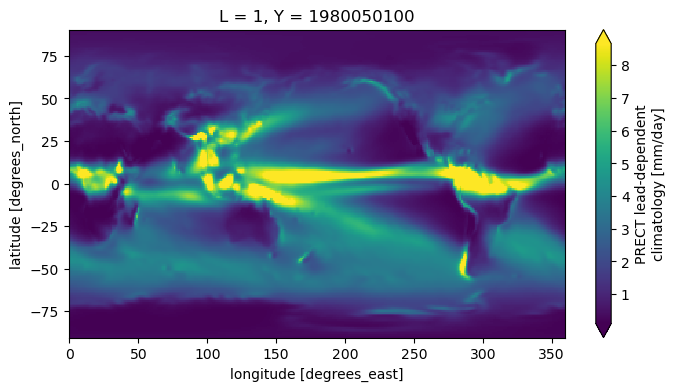

In [7]:
preview_job = JOBS[0]
preview_name = f"{preview_job['variable']}_leadtime_climatology"
with xr.open_dataset(preview_job["output_path"]) as preview_dataset:
    preview = preview_dataset[preview_name].isel(L=0)
    extra_dims = [dim for dim in preview.dims if dim not in {"lat", "lon"}]
    if extra_dims:
        preview = preview.isel({dim: 0 for dim in extra_dims})
    if {"lat", "lon"} <= set(preview.dims):
        preview.plot(robust=True, size=4, aspect=2)
    else:
        preview.plot()